# **PicassoPy Workshop --> Test case: cpv 2024-08-21**
---


- Folder for data `test_case_data` -> download separately
- Folder for configs `test_case_config`


## Imports

In [1]:
import os, sys
import argparse
import datetime
import logging
from pathlib import Path
import numpy as np

sys.path.append('../')
import ppcpy
import ppcpy.io.loadConfigs as loadConfigs
import ppcpy.io.readPollyRawData as readPollyRawData
import ppcpy.interface.picassoProc as picassoProc
import ppcpy.misc.helper as helper
import ppcpy.misc.startscreen as startscreen
from ppcpy.io.write2nc import write_channelwise_2_nc_file, write2nc_file, write_profile2nc_file

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.tab20.colors)

## Defining Script Inputs

- The parameters `args.device`, `args.timestamp`, `args.picasso_config_file`, `args.level0_file_to_process`, need to be manually specified per case.
- The parameter `DATABASE_PATH` is the path to the database used for storing the retrieved calibration constants

In [2]:
## For purpose of the notebook mimic the argparse interface
from types import SimpleNamespace
args = SimpleNamespace()

## The used device and time of mesurment
args.device = 'pollyxt_cpv'
args.timestamp = '20240821'
dt = datetime.datetime.strptime(args.timestamp, "%Y%m%d")

## The used config file
args.picasso_config_file = "test_case_config/pollynet_processing_chain_config_test.json"

## The data file to use
args.level0_file_to_process = f"test_case_data/{dt:%Y_%m_%d_%a}_CPV_00_00_01.nc"


## Database path
DATABASE_PATH = "PicassoPyDatabase.db" # I should test if it works to read this directly from the config files.

In [3]:
startscreen.startscreen()

      ____  _                            ____           ___ ____ 
     / __ \(_)________ _______________  / __ \__  __   <  // __ \
    / /_/ / / ___/ __ `/ ___/ ___/ __ \/ /_/ / / / /   / // / / /
   / ____/ / /__/ /_/ (__  |__  ) /_/ / ____/ /_/ /   / // /_/ / 
  /_/   /_/\___/\__,_/____/____/\____/_/    \__, /   /_(_)____/  
                                           /____/                


## Load Data and Config-files

Loads data and information from the config files into the following three dictionaries:
- `picasso_config_dict`: Paths and other information stored in the picasso config file
- `polly_config_dict`: Configuration variables from polly config and polly default files
- `rawdata_dict`: Measurement data and information extracted from the level0 file

In [4]:
## Path to dafault Picasso config file
picasso_default_config_file = Path(
    helper.detect_path_type(Path.cwd().parent), 'ppcpy', 'config', 'pollynet_processing_chain_config.json')

## Load Picasso config file
picasso_config_dict = loadConfigs.loadPicassoConfig(args.picasso_config_file, picasso_default_config_file)

## load polly config file
polly_config_array = loadConfigs.readPollyNetConfigLinkTable(picasso_config_dict['pollynet_config_link_file'], timestamp=args.timestamp, device=args.device)
polly_config_dict = loadConfigs.getPollyConfigfromArray(
    polly_config_array, picasso_config_dict
)

## Load level0-data file
rawfile_fullname = args.level0_file_to_process
rawfile = helper.detect_path_type(rawfile_fullname)
rawdata_dict = readPollyRawData.readPollyRawData(rawfile)

2026-05-11 10:57:24,990 - INFO - picasso_default_config_file: c:\Users\buholdt\Documents\PicassoPy\ppcpy\config\pollynet_processing_chain_config.json
2026-05-11 10:57:24,992 - INFO - picasso_config_file: test_case_config/pollynet_processing_chain_config_test.json
2026-05-11 10:57:24,993 - INFO - pollynet_config_link_file: test_case_config/pollynet_processing_chain_config_links.xlsx
2026-05-11 10:57:25,239 - INFO - polly_default_config_file: c:\Users\buholdt\Documents\PicassoPy\ppcpy\config\polly_global_config.json
2026-05-11 10:57:25,241 - INFO - polly_config_file: test_case_config\pollyxt_cpv_config_20230927.json
2026-05-11 10:57:25,243 - INFO - keys default/template file, but not in specific file {'flagUseTheoreticalMDR', 'depol_cal_time_fixed_p_end', 'indexing_convention', 'polCaliEtaStd355', 'bgCorRangeIndxHigh', 'molDepol1064', 'zLim_VolDepol_1064', 'zLim_VolDepol_355', 'turbid_thres_par_beta_1064', 'flagMolDepolCali', 'xLim_beta_532_Poliphon', 'yLim_Profi_WV_RH', 'polCaliEta355',

## Initialize PicassoProc object

PicassoProc is the main object in the PicassoPy, and is responsible for running all processes included and storing the data.

In [5]:
## Initialize PicassoProc
data_cube = picassoProc.PicassoProc(rawdata_dict, polly_config_dict, picasso_config_dict)

In [6]:
## reset date if date in filename differs date within nc-file 
data_cube.reset_date_infile()

## checking for correct mshots
data_cube.check_for_correct_mshots()

## setting channelTags
data_cube.setChannelTags()

## check for correct date in nc-file
data_cube.reset_date_infile()

2026-05-11 10:57:25,553 - INFO - date consistency-check... 
2026-05-11 10:57:25,554 - INFO - ... date in nc-file equals date of filename
2026-05-11 10:57:25,555 - INFO - ChannelLabels: ['FR-total-355 nm', 'FR-cross-355 nm', 'FR-387 nm', 'FR-407 nm', 'FR-total-532 nm', 'FR-cross-532 nm', 'FR-607 nm', 'FR-total-1064 nm', 'NR-total-532 nm', 'NR-607 nm', 'NR-total-355 nm', 'NR-387 nm', 'DFOV', '1058', '1064s', 'none']
2026-05-11 10:57:25,556 - WARNING - removed none tag from channel list [15]
2026-05-11 10:57:25,557 - INFO - date consistency-check... 
2026-05-11 10:57:25,558 - INFO - ... date in nc-file equals date of filename


## Preprocessing & Saturation Detection

The preprocessing includes the following processes:
- Deadtime correction
- Background correction
- SNR claculations
- Flagging of data
- Range correction

In [7]:
## Perform preprocessing, this includes Dead-time correction, Background correction, and Range correction
data_cube.preprocessing(collect_debug=True)

2026-05-11 10:57:25,568 - INFO - starting data preprocessing...
2026-05-11 10:57:25,570 - INFO - ... time conversion
2026-05-11 10:57:25,576 - WARNING - ... mShots not constant min 2993 max 2999
2026-05-11 10:57:25,578 - INFO - ... Deadtime-correction (Mode: 1)


mShots_norm (720, 15) mShots_norm [2995.73333333 2995.73333333 2995.73333333 2995.73333333 2995.73333333
 2995.73333333 2995.73333333 2995.73333333 2995.72361111 2995.72361111
 2995.72361111 2995.72361111 2995.72361111 2995.72361111 2995.72361111]


2026-05-11 10:57:29,378 - INFO - ... removing background from signal
2026-05-11 10:57:29,956 - INFO - ... height bin calculations
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\preprocess\pollyPreprocess.py:653: UserWarning: no explicit representation of timezones available for np.datetime64
  data_dict['time64'] = np.array([np.datetime64(t) for t in mTime_obj])
2026-05-11 10:57:30,046 - INFO - ... mask bins with low SNR
2026-05-11 10:57:31,515 - INFO - ... mask for polarization calibration
2026-05-11 10:57:31,518 - INFO - ... calculate range-corrected Signal


flag 532 FR [False False False False  True False False False False False False False
 False False False]
flag 355 FR [ True False False False False False False False False False False False
 False False False]
flag 607 FR [False False False False False False  True False False False False False
 False False False]
flagNDepCal [False False False False False False False False False False False False
  True  True  True  True  True  True  True  True False]
flagPDepCal [False False  True  True  True  True  True  True  True  True False False
 False False False False False False False False False]
depCalPeriods [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0

2026-05-11 10:57:31,796 - INFO - finished data preprocessing.


(720, 4000, 15)
ranges2d (720, 4000)


In [8]:
## Save high resolution signal-to-noise ratio, background, and range corrected signal
write_channelwise_2_nc_file(data_cube=data_cube, prod_ls=['SNR', 'BG', 'RCS'])

2026-05-11 10:57:31,822 - INFO - saving product: SNR
2026-05-11 10:57:31,942 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_SNR.nc
2026-05-11 10:57:34,303 - INFO - saving product: BG
2026-05-11 10:57:34,410 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_BG.nc
2026-05-11 10:57:34,454 - INFO - saving product: RCS
2026-05-11 10:57:34,563 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_RCS.nc


In [9]:
## Display available channels
data_cube.channel_dict

{0: 'FR-total-355 nm',
 1: 'FR-cross-355 nm',
 2: 'FR-387 nm',
 3: 'FR-407 nm',
 4: 'FR-total-532 nm',
 5: 'FR-cross-532 nm',
 6: 'FR-607 nm',
 7: 'FR-total-1064 nm',
 8: 'NR-total-532 nm',
 9: 'NR-607 nm',
 10: 'NR-total-355 nm',
 11: 'NR-387 nm',
 12: 'DFOV',
 13: '1058',
 14: '1064s'}

In [10]:
## Detect and flag saturated signal
data_cube.SaturationDetect()

2026-05-11 10:57:39,343 - INFO - Saturation detection


### Plot Example: Set correct first range bin

The config variable `first_range_gate_index` should indicate the bin at which the signal is reset to 0 after the signal spike.

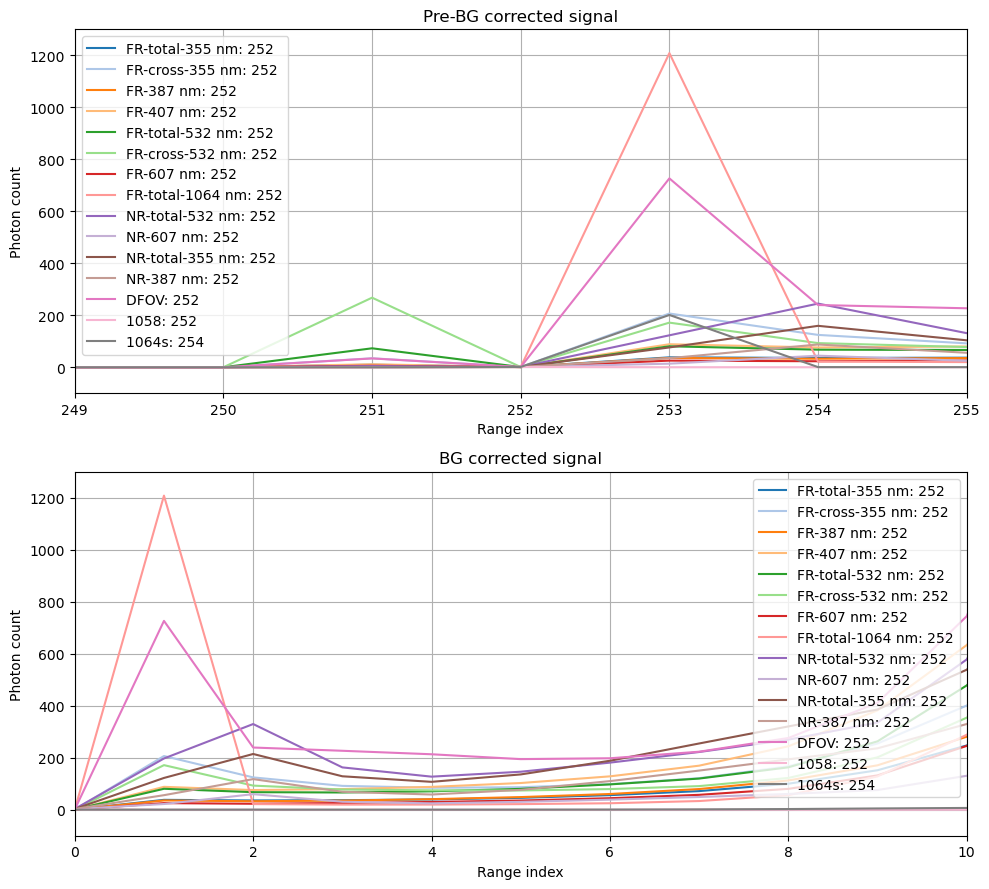

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(10, 9))
for i in range(len(data_cube.channel_dict)):
    ax[0].plot(
        np.nanmean(data_cube.retrievals_highres['preproSignal'][:, :, i], axis=0), 
        label=data_cube.channel_dict[i]+f": {data_cube.polly_config_dict['first_range_gate_indx'][i]}"
    )
    ax[1].plot(
        np.nanmean(data_cube.retrievals_highres['sigBGCor'][:, :, i], axis=0), 
        label=data_cube.channel_dict[i]+f": {data_cube.polly_config_dict['first_range_gate_indx'][i]}"
    )
ax[0].set_xlabel('Range index')
ax[0].set_ylabel('Photon count')
ax[0].set_xlim(249, 255)
ax[0].set_ylim(-100, 1300)
ax[0].grid()
ax[0].legend()
ax[0].set_title("Pre-BG corrected signal")
ax[1].set_xlabel('Range index')
ax[1].set_ylabel('Photon count')
ax[1].set_xlim(0, 10)
ax[1].set_ylim(-100, 1300)
ax[1].grid()
ax[1].legend(loc="upper right")
ax[1].set_title("BG corrected signal")
fig.tight_layout()

### Plot example: Range corrected signal

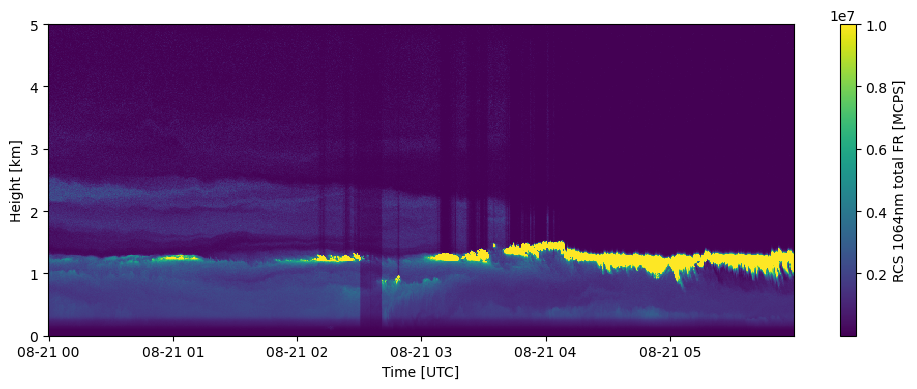

In [12]:
fig, ax = plt.subplots(figsize=(10, 4))
pcmesh = ax.pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    np.squeeze(data_cube.retrievals_highres['RCS'][:, :, data_cube.gf(1064, 'total', 'FR')]).T,
    shading='nearest',
    vmin=5, vmax=1e7
)
cbar = fig.colorbar(pcmesh)
cbar.set_label('RCS 1064nm total FR [MCPS]')
ax.set_xlabel('Time [UTC]')
ax.set_ylabel('Height [km]')
ax.set_ylim(0, 5)
fig.tight_layout()

## Depol Calibration


- Depol. calibration constants (DC) are retrieved at each depol. calibration period included in the data
- All retrieved DCs are stored in a dedicated database
- The optimal retrieved DC, ie. the one with the lowest standard deviation (std) is used for the processing
- If no DCs can be retirieved, the DC with the lowest std in the time range [24h before the measurement, 24h after the measurement] included in the database will be used

In [13]:
## Delta 90 polarization calibration
data_cube.polarizationCaliD90()

2026-05-11 10:57:47,702 - INFO - and even a 355 channel
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\calibration\polarization.py:314: RuntimeWarning: divide by zero encountered in divide
  dplus = smooth_signal(sig_x_p, smooth_win) / smooth_signal(sig_t_p, smooth_win)
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\calibration\polarization.py:314: RuntimeWarning: invalid value encountered in divide
  dplus = smooth_signal(sig_x_p, smooth_win) / smooth_signal(sig_t_p, smooth_win)
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\calibration\polarization.py:315: RuntimeWarning: divide by zero encountered in divide
  dminus = smooth_signal(sig_x_m, smooth_win) / smooth_signal(sig_t_m, smooth_win)
2026-05-11 10:57:47,773 - INFO - pol_cali_355  [{'eta': 47.742418057789656, 'eta_std': 1.0396617649540707, 'time_start': 1724207790, 'time_end': 1724208000, 'status': 1}]
2026-05-11 10:57:47,774 - INFO - and even a 532 channel
2026-05-11 10:57:47,842 - INFO - pol_cali_532  [{'eta': 1

starting loadGHK
data_cube keys  dict_keys(['rawfile', 'rawdata_dict', 'polly_config_dict', 'picasso_config_dict', 'device', 'location', 'date', 'num_of_channels', 'num_of_profiles', 'retrievals_highres', 'retrievals_profile', 'pol_cali', 'LC', 'channel_dict', 'flags', 'flag_355_total_FR', 'flag_355_cross_FR', 'flag_355_parallel_FR', 'flag_355_total_NR', 'flag_387_total_FR', 'flag_387_total_NR', 'flag_407_total_FR', 'flag_407_total_NR', 'flag_532_total_FR', 'flag_532_cross_FR', 'flag_532_parallel_FR', 'flag_532_total_NR', 'flag_532_cross_DFOV', 'flag_532_rr_FR', 'flag_607_total_FR', 'flag_607_total_NR', 'flag_1058_total_FR', 'flag_1064_total_FR', 'flag_1064_cross_FR', 'flag_1064_total_NR', 'flagSaturation'])
Using GHK from config file
G [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
H [ 0.02041 -0.998    1.       1.      -0.01477 -0.9987   1.      -0.02439
  1.       1.       1.       1.       1.       1.      -0.996  ]
K [0.97859 1.      1.      1.      0.99343 1.      1.      0.9947 

2026-05-11 10:57:47,905 - INFO - Using retieved polarization calibration constants.


In [14]:
## Display depolarization calibration constants
data_cube.etaused

{'355_FR': np.float64(47.742418057789656),
 '532_FR': np.float64(12.380587648929659),
 '1064_FR': np.float64(0.14153155793311498)}

## Cloud Screening

Three modes of cloud Screening are currently implemented:

0. No cloud screening. Return cloud free for all timestamps
1. Cloud screen with Maximum Gradiant Signal (MSG) algorithm
2. Cloud screen with Zhao's algorithm

Clouds are screened per timestamp (30s). After the screening the data is splitt up into cloud free segments and aggregated.

In [15]:
## Apply cloud screening
data_cube.cloudScreen()

2026-05-11 10:57:47,924 - INFO - cloud screen mode 1: MSG method.


Starting cloud screen


In [16]:
## Segmentate cloud free groups
data_cube.cloudFreeSeg()

intNProfiles 120 minIntNProfiles 30


In [17]:
## Display cloud free groups
data_cube.clFreeGrps

array([[  0, 113],
       [144, 244]])

### Plot example: Cloud free groups

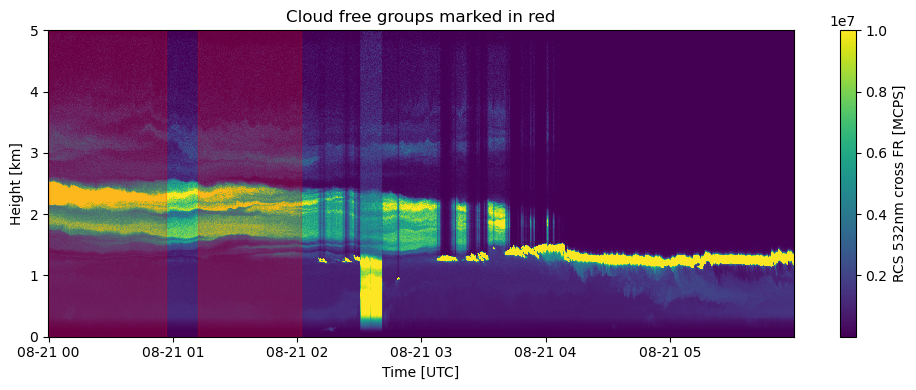

In [18]:
wv, t, tel = 532, 'cross', 'FR'

fig, ax = plt.subplots(figsize=(10, 4))
pcmesh = ax.pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    np.squeeze(data_cube.retrievals_highres['RCS'][:, :, data_cube.gf(wv, t, tel)]).T,
    shading='nearest',
    vmin=5, vmax=1e7
)
for cldFreGrp in data_cube.clFreeGrps:
    ax.axvspan(
        data_cube.retrievals_highres["time64"][cldFreGrp[0]],
        data_cube.retrievals_highres["time64"][cldFreGrp[1]],
        color="red", alpha=0.2
    )

cbar = fig.colorbar(pcmesh)
cbar.set_label(f'RCS {wv}nm {t} {tel} [MCPS]')
ax.set_xlabel('Time [UTC]')
ax.set_ylabel('Height [km]')
ax.set_title('Cloud free groups marked in red')
ax.set_ylim(0, 5)
fig.tight_layout()

In [19]:
## Aggregate background, background corrected signal, and range corrected signal
data_cube.aggregate_profiles()

### Plot example: Aggregated profiles

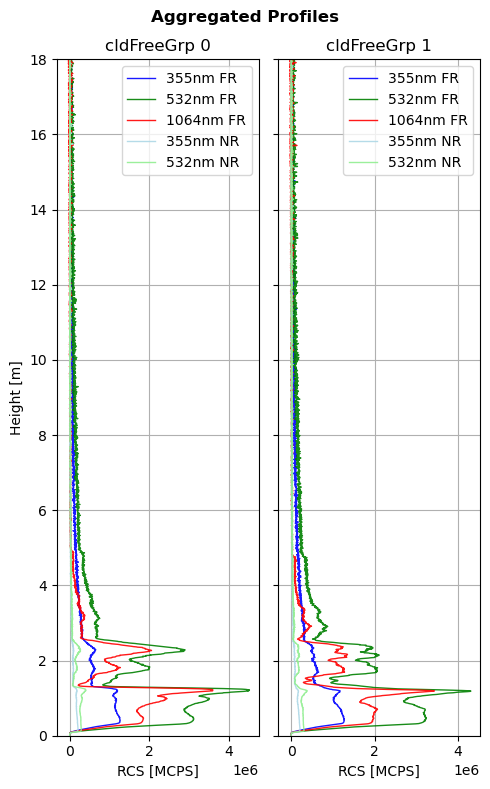

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(5, 8), sharey=True)
ax[0].plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR')
ax[0].plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR')
ax[0].plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(1064, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR')
ax[0].plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(355, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm NR')
ax[0].plot(np.squeeze(data_cube.retrievals_profile['RCS'][0, :, data_cube.gf(532, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm NR')
ax[0].grid()
ax[0].set_ylim(0, 18)
ax[0].legend(loc='upper right')
ax[0].set_ylabel('Height [m]')
ax[0].set_xlabel('RCS [MCPS]')
ax[0].set_title('cldFreeGrp 0')

ax[1].plot(np.squeeze(data_cube.retrievals_profile['RCS'][1, :, data_cube.gf(355, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR')
ax[1].plot(np.squeeze(data_cube.retrievals_profile['RCS'][1, :, data_cube.gf(532, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR')
ax[1].plot(np.squeeze(data_cube.retrievals_profile['RCS'][1, :, data_cube.gf(1064, 'total', 'FR')]), data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR')
ax[1].plot(np.squeeze(data_cube.retrievals_profile['RCS'][1, :, data_cube.gf(355, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm NR')
ax[1].plot(np.squeeze(data_cube.retrievals_profile['RCS'][1, :, data_cube.gf(532, 'total', 'NR')]), data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm NR')
ax[1].grid()
ax[1].set_ylim(0, 18)
ax[1].legend(loc='upper right')
ax[1].set_xlabel('RCS [MCPS]')
ax[1].set_title('cldFreeGrp 1')
fig.suptitle("Aggregated Profiles", fontweight='bold')
fig.tight_layout()


## Molecular Profiles

The molecular profiles are calculated from cloudNet ECMWF model data. Gdas1 data is not supported in PicassoPy!

In [21]:
## QuickFix for loadMeteo bug:
METEO_DATA_DIR_PATH = "E:\\data\\level1a\\cloudnet\\mindelo\\calibrated\\ecmwf"
data_cube.polly_config_dict['meteorDataSource'] = 'nc_cloudnet'
data_cube.polly_config_dict['meteo_folder'] = METEO_DATA_DIR_PATH
data_cube.polly_config_dict['meteo_file'] = r"[\\/]{0:%Y}[\\/]{0:%Y%m%d}_.*\.nc"

## Load meteorological data
data_cube.loadMeteo()

## Calculate molecular profiles
data_cube.calcMolecular()

c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\io\readMeteo.py:263: FutureWarning: In a future version, xarray will not decode the variable 'forecast_time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds = xr.load_dataset(filename)
2026-05-11 10:57:52,011 - INFO - Performing model height correction.
2026-05-11 10:57:52,013 - INFO - Uncorrected model height[:,0]:
[10.466079  10.4652    10.460253  10.455192  10.449221  10.447984
 10.453651  10.460172  10.464973  10.472917  10.479133  10.485509
 10.4861145 10.477216  10.487477  10.491782  10.485256  10.4855

time slices of cloud free  [array(['2024-08-21T00:00:00.000000', '2024-08-21T00:56:30.000000'],
      dtype='datetime64[us]'), array(['2024-08-21T01:12:00.000000', '2024-08-21T02:02:00.000000'],
      dtype='datetime64[us]')]
get_mean_profiles(time_slice: <class 'list'>) -> <class 'list'>
len mean_profiles 2
shape of the molecular scattering (2, 4000)
for the wavelengths  [355, 387, 407, 532, 607, 1058, 1064]


### Plot example: Molecular Backscatter and Extinction

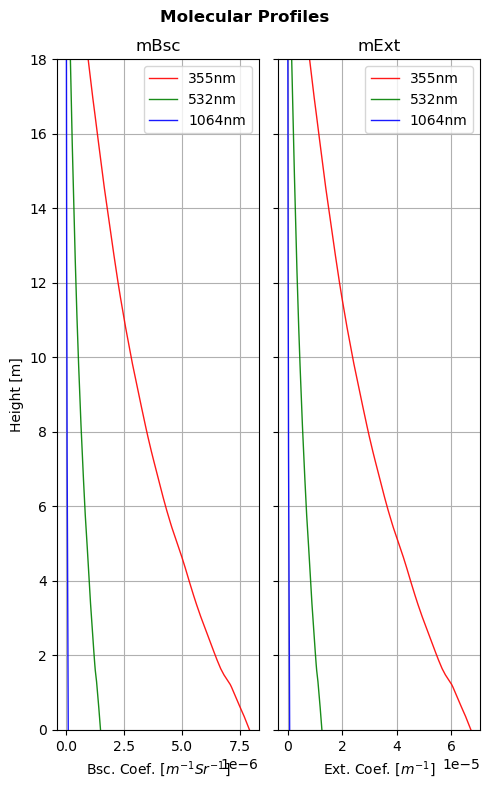

In [22]:
grpIdx = 1

fig, ax = plt.subplots(1, 2, figsize=(5, 8), sharey=True)
## Molecular Backscatter
ax[0].plot(data_cube.mol_profiles['mBsc_355'][grpIdx], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='355nm')
ax[0].plot(data_cube.mol_profiles['mBsc_532'][grpIdx], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm')
ax[0].plot(data_cube.mol_profiles['mBsc_1064'][grpIdx], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='1064nm')
ax[0].grid()
ax[0].set_ylim(0, 18)
ax[0].legend(loc='upper right')
ax[0].set_ylabel('Height [m]')
ax[0].set_xlabel('Bsc. Coef. $[m^{-1}Sr^{-1}]$')
ax[0].set_title('mBsc')

## Molecular Extinction
ax[1].plot(data_cube.mol_profiles['mExt_355'][grpIdx], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='355nm')
ax[1].plot(data_cube.mol_profiles['mExt_532'][grpIdx], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm')
ax[1].plot(data_cube.mol_profiles['mExt_1064'][grpIdx], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='1064nm')
ax[1].grid()
ax[1].set_ylim(0, 18)
ax[1].legend(loc='upper right')
ax[1].set_xlabel('Ext. Coef. $[m^{-1}]$')
ax[1].set_title('mExt')
fig.suptitle("Molecular Profiles", fontweight='bold')
fig.tight_layout()


## Rayleigh-Fit

- Douglas-Peucker algorithm is used to segment the signal into potential reference heights
- The reference height with the best fit to the molecular backscatter per channel is chosen
- Currently only done for FR-channels. NR reference heights are read from the config variables `refH_NR_{wavelength}`

In [23]:
## Rayleigh-fit procedure --> produces the reference heights
data_cube.rayleighFit()

2026-05-11 10:57:53,733 - WARNING - Potential for differences to matlab code due to numerical issues (subtraction of two small values)
2026-05-11 10:57:53,734 - WARNING - rayleighfit seems to use range in matlab, but the met data should be in height >> RECHECK!
2026-05-11 10:57:53,735 - WARNING - at 10km height this is a difference of about 4 indices


Start Rayleigh Fit
0 [  0 113]
refH for 532
DPInd: [ 107  508  509  910  911 1312 1313 1714 1715 2116 2117 2408]
refInd: (2117, 2408)
refH for 355
DPInd: [ 120  922  923 1725 1726 2408]
refInd: (923, 1725)
refH for 1064
DPInd: [ 107  374  375  642  643  687  954  955 1222 1223 1490 1491 1758 1759
 1814 1837 1846 1847 1870 1943 1954 1958 2003 2056 2064 2068 2069 2076
 2084 2097 2125 2126 2137 2140 2145 2158 2159 2170 2186 2244 2319 2361
 2395 2396 2409 2436 2507 2510 2535 2543 2546 2552 2584 2603 2604 2607
 2638 2689 2795 2846 2858 2902 2906 2913 2926 2927 2935 2952 2954 2957
 2983 2999 3001 3002 3030 3038 3041 3045 3046 3047 3060 3063 3072 3084
 3086 3094 3109 3158 3183 3191 3209 3214 3296 3309 3313 3323 3341]
one tests failed?
refInd: (1759, 1814)
1 [144 244]
refH for 532
DPInd: [ 107  508  509  910  911 1312 1313 1714 1715 2116 2117 2408]
refInd: (1715, 2116)
refH for 355
DPInd: [ 120  922  923 1725 1726 2407]
refInd: (1726, 2407)
refH for 1064


c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\calibration\rayleighfit.py:571: RuntimeWarning: divide by zero encountered in divide
  std_aer_norm = sig_aer_norm / np.sqrt(pc + bg)
2026-05-11 10:57:54,008 - INFO - Using Config values for NR refH.


DPInd: [ 107  374  375  642  643  693  960  961 1228 1229 1496 1497 1764 1765
 1938 2069 2099 2121 2122 2164 2179 2201 2338 2377 2475 2531 2602 2637
 2644 2650 2675 2719 2730 2784 2816 2840 2878 2918 2932 2959 2966 2973
 2997 3010 3048 3061 3124 3132 3133 3134 3178 3202 3227 3271 3274 3339
 3344]
one tests failed?
one tests failed?
one tests failed?
refInd: (1938, 2069)


In [24]:
## Display reference heights for a given cloud free group
grpIdx = 0
print(f"""Reference heights in meters for cloud free period {grpIdx} {data_cube.retrievals_highres['time64'][data_cube.clFreeGrps[grpIdx]]}:
355 total FR:  {np.round(data_cube.retrievals_profile['refH'][grpIdx]["355_total_FR"]['refHeight'], 0)}
532 total FR:  {np.round(data_cube.retrievals_profile['refH'][grpIdx]["532_total_FR"]['refHeight'], 0)}
1064 total FR: {np.round(data_cube.retrievals_profile['refH'][grpIdx]["1064_total_FR"]['refHeight'], 0)}
355 total NR:  {np.round(data_cube.retrievals_profile['refH'][grpIdx]["355_total_NR"]['refHeight'], 0)}
532 total NR:  {np.round(data_cube.retrievals_profile['refH'][grpIdx]["532_total_NR"]['refHeight'], 0)}""")

Reference heights in meters for cloud free period 0 ['2024-08-21T00:00:00.000000' '2024-08-21T00:56:30.000000']:
355 total FR:  [ 6877. 12849.]
532 total FR:  [15768. 17935.]
1064 total FR: [13102. 13512.]
355 total NR:  [3005. 3995.]
532 total NR:  [3005. 3995.]


## GHK-Transmission Correction

In [25]:
## Molecular polarization calibration 
data_cube.polarizationCaliMol()

2026-05-11 10:57:54,097 - WARNING - not checked against the matlab code
2026-05-11 10:57:54,098 - WARNING - 'flagMolDepolCali' set to False


In [26]:
## Apply GHK-transmission correction
data_cube.transCor()

2026-05-11 10:57:54,158 - WARNING - transmission correction
2026-05-11 10:57:54,223 - INFO - and even a 355 channel
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\depolarization.py:168: RuntimeWarning: divide by zero encountered in divide
  sig_ratio = sigc / sigt
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\depolarization.py:168: RuntimeWarning: invalid value encountered in divide
  sig_ratio = sigc / sigt
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\depolarization.py:178: RuntimeWarning: invalid value encountered in divide
  vol_depol = (sig_ratio / eta * (Gt + Ht) - (Gr + Hr)) / ((Gr - Hr) - sig_ratio / eta * (Gt - Ht))
2026-05-11 10:57:54,456 - INFO - and even a 532 channel


G [1.] [1.]
H [0.02041] [-0.998]
polCaliEta 47.742418057789656
G [1.] [1.] H [0.02041] [-0.998] Eta 47.742418057789656 error [ 0.00016  0.01567 -0.00958] Window 1 
calculated R_t [0.95999647]


2026-05-11 10:57:54,654 - INFO - and even a 1064 channel


G [1.] [1.]
H [-0.01477] [-0.9987]
polCaliEta 12.380587648929659
G [1.] [1.] H [-0.01477] [-0.9987] Eta 12.380587648929659 error [ 0.00027  0.02024 -0.00463] Window 1 
calculated R_t [1.02998285]
G [1.] [1.]
H [-0.02439] [-0.996]
polCaliEta 0.14153155793311498
G [1.] [1.] H [-0.02439] [-0.996] Eta 0.14153155793311498 error [ 0.00133  0.02379 -0.01205] Window 1 
calculated R_t [1.04999949]


In [27]:
## Aggregate GHK-transmission corrected profiles
data_cube.aggregate_profiles(var='sigTCor')
data_cube.aggregate_profiles(var='BGTCor')

## Klett and Raman retrieval

Produces the following profiles per channel:
- Klett: Aerosol Backscatter and Extinction
- Raman: Aerosol Backscatter, Aerosol Extinction, and Lidar Ratio

If `nr=True`, perform the retrievals for FR and NR channels. Otherwise only FR.

In [28]:
## Klett retrieval for GHK-transmisson corrected profiles
data_cube.retrievalKlett(nr=True)

2026-05-11 10:57:54,922 - WARNING - rayleighfit seems to use range in matlab, but the met data should be in height >> RECHECK!
2026-05-11 10:57:54,923 - WARNING - at 10km height this is a difference of about 4 indices


retrievalname klett
Starting Klett retrieval
cldFree  0 [  0 113]
cldFree mod (np.int64(0), np.int64(114))
== 532, total, FR klett =================================
== 355, total, FR klett =================================
== 1064, total, FR klett =================================
== 532, total, NR klett =================================
== 355, total, NR klett =================================
cldFree  1 [144 244]
cldFree mod (np.int64(144), np.int64(245))
== 532, total, FR klett =================================
== 355, total, FR klett =================================
== 1064, total, FR klett =================================
== 532, total, NR klett =================================
== 355, total, NR klett =================================


c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\klettfernald.py:311: RuntimeWarning: invalid value encountered in divide
  aerRelBRStd = np.abs((1 + noise / signal) / (1 + aerBsc + molBsc / 1e3) - 1)


### Plot example: Klett retrieved optical profiles

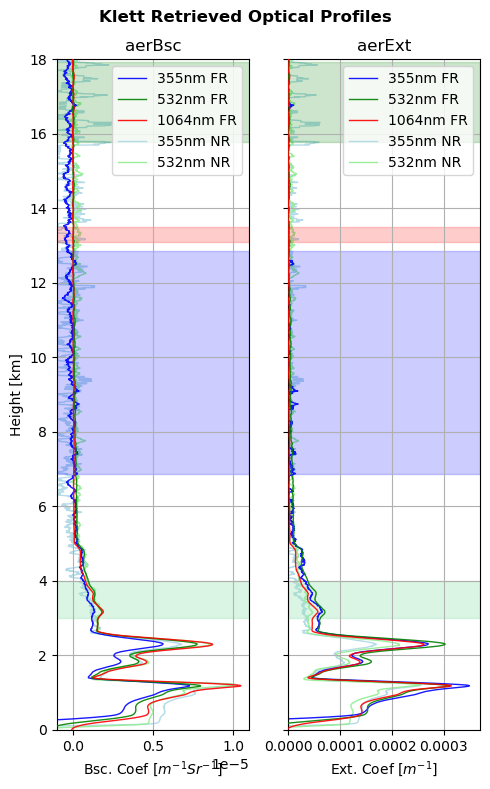

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(5, 8), sharey=True)
## Aerosol backscatter
ax[0].plot(data_cube.retrievals_profile['klett'][grpIdx]['355_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR', zorder=2)
ax[0].plot(data_cube.retrievals_profile['klett'][grpIdx]['532_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR', zorder=3)
ax[0].plot(data_cube.retrievals_profile['klett'][grpIdx]['1064_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR', zorder=4)
ax[0].plot(data_cube.retrievals_profile['klett'][grpIdx]['355_total_NR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm NR', zorder=0)
ax[0].plot(data_cube.retrievals_profile['klett'][grpIdx]['532_total_NR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm NR', zorder=1)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_NR']['refHeight'])/1000,  color='lightblue', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_NR']['refHeight'])/1000,  color='lightgreen', alpha=0.2)
ax[0].grid()
ax[0].set_ylim(0, 18)
ax[0].set_xlim(-1e-6, 11e-6)
ax[0].legend(loc='upper right')
ax[0].set_ylabel('Height [km]')
ax[0].set_xlabel('Bsc. Coef $[m^{-1}Sr^{-1}]$')
ax[0].set_title('aerBsc')

## Aerosol Extinction
ax[1].plot(data_cube.retrievals_profile['klett'][grpIdx]['355_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR', zorder=2)
ax[1].plot(data_cube.retrievals_profile['klett'][grpIdx]['532_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR', zorder=3)
ax[1].plot(data_cube.retrievals_profile['klett'][grpIdx]['1064_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR', zorder=4)
ax[1].plot(data_cube.retrievals_profile['klett'][grpIdx]['355_total_NR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355nm NR', zorder=0)
ax[1].plot(data_cube.retrievals_profile['klett'][grpIdx]['532_total_NR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532nm NR', zorder=1)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_NR']['refHeight'])/1000,  color='lightblue', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_NR']['refHeight'])/1000,  color='lightgreen', alpha=0.2)
ax[1].grid()
ax[1].set_ylim(0, 18)
ax[1].set_xlim(-1e-6, 3.7e-4)
ax[1].legend(loc='upper right')
ax[1].set_xlabel('Ext. Coef $[m^{-1}]$')
ax[1].set_title('aerExt')
fig.suptitle("Klett Retrieved Optical Profiles", fontweight='bold')
fig.tight_layout()

In [30]:
## Raman retrieval for GHK-transmisson corrected profiles
data_cube.retrievalRaman(nr=True)

2026-05-11 10:57:55,616 - WARNING - rayleighfit seems to use range in matlab, but the met data should be in height >> RECHECK!
2026-05-11 10:57:55,617 - WARNING - at 10km height this is a difference of about 4 indices
c:\Users\buholdt\AppData\Local\miniconda3\envs\PicassoPy\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


[array([900, 900, 900, 900, 800, 800, 800, 800, 150, 150, 150, 150, 150,
       800, 800]), array([900, 900, 900, 900, 800, 800, 800, 800, 150, 150, 150, 150, 150,
       800, 800])]
Starting Raman retrieval
cldFree  0 [  0 113]
cldFree mod (np.int64(0), np.int64(114))
== 355, total, FR | 387, total, FR raman ========
900 370.01248
refHInd (923, 1725) refH [ 6903.17491198 12898.12483549] hBaseInd 170 hBase 1274.4999837875366
filling aerExt below overlap with 0.00010661377423382957 for calculating the backscatter


c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\raman.py:525: RuntimeWarning: invalid value encountered in sqrt
  sigElasticSample = sigGenWithNoise(sigElastic, np.sqrt(sigElastic + bgElastic), MC_count[2], 'norm').T


== 532, total, FR | 607, total, FR raman ========
800 370.01248
refHInd (2117, 2408) refH [15828.32479811 18003.54977036] hBaseInd 157 hBase 1177.3249850273132
filling aerExt below overlap with 0.00010067973285248971 for calculating the backscatter
== 1064, total, FR | 607, total, FR raman ========
800 370.01248
refHInd (1759, 1814) refH [13152.27483225 13563.399827  ] hBaseInd 157 hBase 1177.3249850273132
filling aerExt below overlap with 8.177735427394038e-05 for calculating the backscatter
== 532, total, NR | 607, total, NR raman ========
150 190.6125
refHInd [403, 536] refH [3016.17496157 4010.34994888] hBaseInd 46 hBase 347.59999561309814
filling aerExt below overlap with 0.00010918399070423215 for calculating the backscatter


c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\raman.py:362: RuntimeWarning: invalid value encountered in sqrt
  noise = np.sqrt(sig + bg)
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\raman.py:526: RuntimeWarning: invalid value encountered in sqrt
  sigVRN2Sample = sigGenWithNoise(sigVRN2, np.sqrt(sigVRN2 + bgVRN2), MC_count[2], 'norm').T


== 355, total, NR | 387, total, NR raman ========
150 190.6125
refHInd [403, 536] refH [3016.17496157 4010.34994888] hBaseInd 46 hBase 347.59999561309814
filling aerExt below overlap with 0.00010872964355742773 for calculating the backscatter
cldFree  1 [144 244]
cldFree mod (np.int64(144), np.int64(245))
== 355, total, FR | 387, total, FR raman ========
900 370.01248
refHInd (1726, 2407) refH [12905.5998354  17996.07477045] hBaseInd 170 hBase 1274.4999837875366
filling aerExt below overlap with 8.681196683899163e-05 for calculating the backscatter
== 532, total, FR | 607, total, FR raman ========
800 370.01248
refHInd (1715, 2116) refH [12823.37483644 15820.8497982 ] hBaseInd 157 hBase 1177.3249850273132
filling aerExt below overlap with 8.292641830103832e-05 for calculating the backscatter
== 1064, total, FR | 607, total, FR raman ========
800 370.01248
refHInd (1938, 2069) refH [14490.29981518 15469.52480268] hBaseInd 157 hBase 1177.3249850273132
filling aerExt below overlap with 6.

### Plot example: Raman retrieved optical profiles

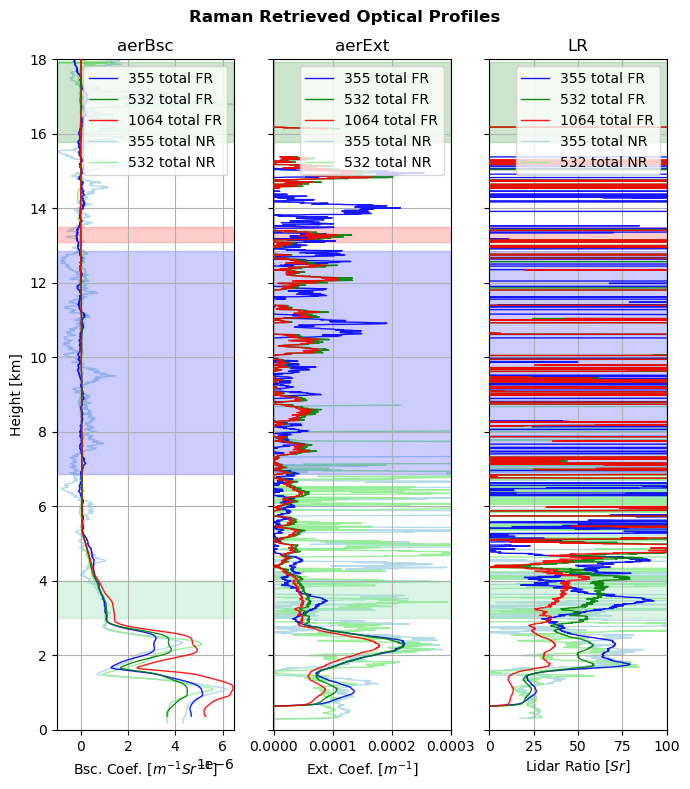

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(7, 8), sharey=True)
## Aerosol backscatter
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355 total FR', zorder=2)
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532 total FR', zorder=3)
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['1064_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064 total FR', zorder=4)
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_NR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355 total NR', zorder=0)
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_NR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532 total NR', zorder=1)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_NR']['refHeight'])/1000,  color='lightblue', alpha=0.2)
ax[0].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_NR']['refHeight'])/1000,  color='lightgreen', alpha=0.2)
ax[0].grid()
ax[0].set_ylim(0, 18)
ax[0].set_xlim(-1e-6, 6.5e-6)
ax[0].legend(loc='upper right')
ax[0].set_ylabel('Height [km]')
ax[0].set_xlabel('Bsc. Coef. $[m^{-1}Sr^{-1}]$')
ax[0].set_title('aerBsc')

## Aerosol Extinction
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355 total FR', zorder=2)
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532 total FR', zorder=3)
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['1064_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064 total FR', zorder=4)
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_NR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355 total NR', zorder=0)
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_NR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532 total NR', zorder=1)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_NR']['refHeight'])/1000,  color='lightblue', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_NR']['refHeight'])/1000,  color='lightgreen', alpha=0.2)
ax[1].grid()
ax[1].set_ylim(0, 18)
ax[1].set_xlim(-1e-6, 3e-4)
ax[1].legend(loc='upper right')
ax[1].set_xlabel('Ext. Coef. $[m^{-1}]$')
ax[1].set_title('aerExt')

## Lidar Ratio
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['LR'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355 total FR', zorder=2)
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_FR']['LR'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532 total FR', zorder=3)
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['1064_total_FR']['LR'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064 total FR', zorder=4)
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_NR']['LR'], data_cube.retrievals_highres['height']/1000, color='lightblue', alpha=0.9, linewidth=1, label='355 total NR', zorder=0)
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_NR']['LR'], data_cube.retrievals_highres['height']/1000, color='lightgreen', alpha=0.9, linewidth=1, label='532 total NR', zorder=1)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_NR']['refHeight'])/1000,  color='lightblue', alpha=0.2)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_NR']['refHeight'])/1000,  color='lightgreen', alpha=0.2)
ax[2].grid()
ax[2].set_ylim(0, 18)
ax[2].set_xlim(0, 100)
ax[2].legend(loc='upper right')
ax[2].set_xlabel('Lidar Ratio $[Sr]$')
ax[2].set_title('LR')
fig.suptitle("Raman Retrieved Optical Profiles", fontweight='bold')
fig.tight_layout()

## Overlap Correction

Two methods are available for calculating the Overlap Function:

1. FRNR method
2. Raman method

And four methods (currently only 3 implemented) are available for applying the Overlap Correction:

0. no overlap correction
1. overlap correction with using the default overlap function (read function from file)
2. overlap correction with using the calculated overlap function
3. overlap correction with gluing near-range and far-range signal -> Not implemented yet!


In [32]:
## Calculate overlap function
data_cube.overlapCalc()

## Fix spike in lower bins
data_cube.overlapFixLowestBins()

## Apply overlap correction
data_cube.overlapCor()

2026-05-11 10:58:01,439 - WARNING - rayleighfit seems to use range in matlab, but the met data should be in height >> RECHECK!
2026-05-11 10:58:01,440 - WARNING - at 10km height this is a difference of about 4 indices


Starting Overlap retrieval
cldFree 0 [  0 113]
cldFree mod (np.int64(0), np.int64(114))
355 both telescopes available
387 both telescopes available
532 both telescopes available
607 both telescopes available
cldFree 1 [144 244]
cldFree mod (np.int64(144), np.int64(245))
355 both telescopes available


c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\misc\helper.py:910: RuntimeWarning: invalid value encountered in scalar divide
  relStd.append(thisStd / abs(thisMean))


387 both telescopes available
532 both telescopes available
607 both telescopes available


2026-05-11 10:58:03,562 - WARNING - rayleighfit seems to use range in matlab, but the met data should be in height >> RECHECK!
2026-05-11 10:58:03,563 - WARNING - at 10km height this is a difference of about 4 indices


Starting Raman Overlap retrieval
cldFree  0 [  0 113]
cldFree mod (np.int64(0), np.int64(114))
532 607 both wavelengths available
355 387 both wavelengths available
cldFree  1 [144 244]
cldFree mod (np.int64(144), np.int64(245))
532 607 both wavelengths available
355 387 both wavelengths available


2026-05-11 10:58:08,558 - INFO - overlap Correction


Fixing lower bins for frnr overlap functions
Fixing lower bins for raman overlap functions
overlapCorMode  2  overlapCalMode  2
dict_keys(['frnr', 'raman'])
overlap correction source raman
[array(['2024-08-21T00:00:00.000000', '2024-08-21T00:56:30.000000'],
      dtype='datetime64[us]'), array(['2024-08-21T01:12:00.000000', '2024-08-21T02:02:00.000000'],
      dtype='datetime64[us]')] ['2024-08-21T00:00:00.000000' '2024-08-21T00:56:30.000000'
 '2024-08-21T01:12:00.000000' '2024-08-21T02:02:00.000000']
[[  0 113]
 [144 244]]
532_total_FR len(olFuncs) 2 2 2
(4, 4000)
(720, 4000)
355_total_FR len(olFuncs) 2 2 2
(4, 4000)
(720, 4000)
correct overlap 355
correct overlap 387
using 355 instead of 387
correct overlap 532
correct overlap 607
using 532 instead of 607
correct overlap 1064
using 532 instead of 1064


In [33]:
## Aggregate overlap corrected profiles
data_cube.aggregate_profiles('sigOLCor')
data_cube.aggregate_profiles('BGOLCor')

In [34]:
## Klett retrieval for overlap corrected profiles
data_cube.retrievalKlett(oc=True)

## Raman retrieval for overlap corrected profiles
data_cube.retrievalRaman(oc=True)

2026-05-11 10:58:08,962 - WARNING - rayleighfit seems to use range in matlab, but the met data should be in height >> RECHECK!
2026-05-11 10:58:08,963 - WARNING - at 10km height this is a difference of about 4 indices


retrievalname klett_OC
Starting Klett retrieval
cldFree  0 [  0 113]
cldFree mod (np.int64(0), np.int64(114))
== 532, total, FR klett =================================
== 355, total, FR klett =================================
== 1064, total, FR klett =================================


c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\klettfernald.py:277: RuntimeWarning: invalid value encountered in scalar divide
  denominator1 = RCS[iAlt + 1] / (aerBsc[iAlt + 1] + molBsc[iAlt + 1])
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\klettfernald.py:311: RuntimeWarning: divide by zero encountered in divide
  aerRelBRStd = np.abs((1 + noise / signal) / (1 + aerBsc + molBsc / 1e3) - 1)
2026-05-11 10:58:09,106 - WARNING - rayleighfit seems to use range in matlab, but the met data should be in height >> RECHECK!
2026-05-11 10:58:09,107 - WARNING - at 10km height this is a difference of about 4 indices


cldFree  1 [144 244]
cldFree mod (np.int64(144), np.int64(245))
== 532, total, FR klett =================================
== 355, total, FR klett =================================
== 1064, total, FR klett =================================
[array([138., 900., 138., 900., 130., 800., 130., 130., 150., 150., 150.,
       150., 150., 800., 800.]), array([138., 900., 138., 900., 130., 800., 130., 130., 150., 150., 150.,
       150., 150., 800., 800.])]
Starting Raman retrieval
cldFree  0 [  0 113]
cldFree mod (np.int64(0), np.int64(114))
== 355, total, FR | 387, total, FR raman ========


c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\raman.py:339: RuntimeWarning: divide by zero encountered in divide
  temp = number_density / (sig * height**2)


138.0 370.01248
refHInd (923, 1725) refH [ 6903.17491198 12898.12483549] hBaseInd 68 hBase 512.0499935150146
filling aerExt below overlap with 0.00022117783215994086 for calculating the backscatter
== 532, total, FR | 607, total, FR raman ========
130.0 370.01248
refHInd (2117, 2408) refH [15828.32479811 18003.54977036] hBaseInd 67 hBase 504.5749936103821
filling aerExt below overlap with 0.00015649698999919176 for calculating the backscatter
== 1064, total, FR | 607, total, FR raman ========
130.0 370.01248
refHInd (1759, 1814) refH [13152.27483225 13563.399827  ] hBaseInd 67 hBase 504.5749936103821
filling aerExt below overlap with 0.00012711505514938134 for calculating the backscatter
cldFree  1 [144 244]
cldFree mod (np.int64(144), np.int64(245))
== 355, total, FR | 387, total, FR raman ========
138.0 370.01248
refHInd (1726, 2407) refH [12905.5998354  17996.07477045] hBaseInd 68 hBase 512.0499935150146
filling aerExt below overlap with 0.00022633148478896803 for calculating the ba

### Plot example: Overlap Corrected Raman retrieved optical profiles

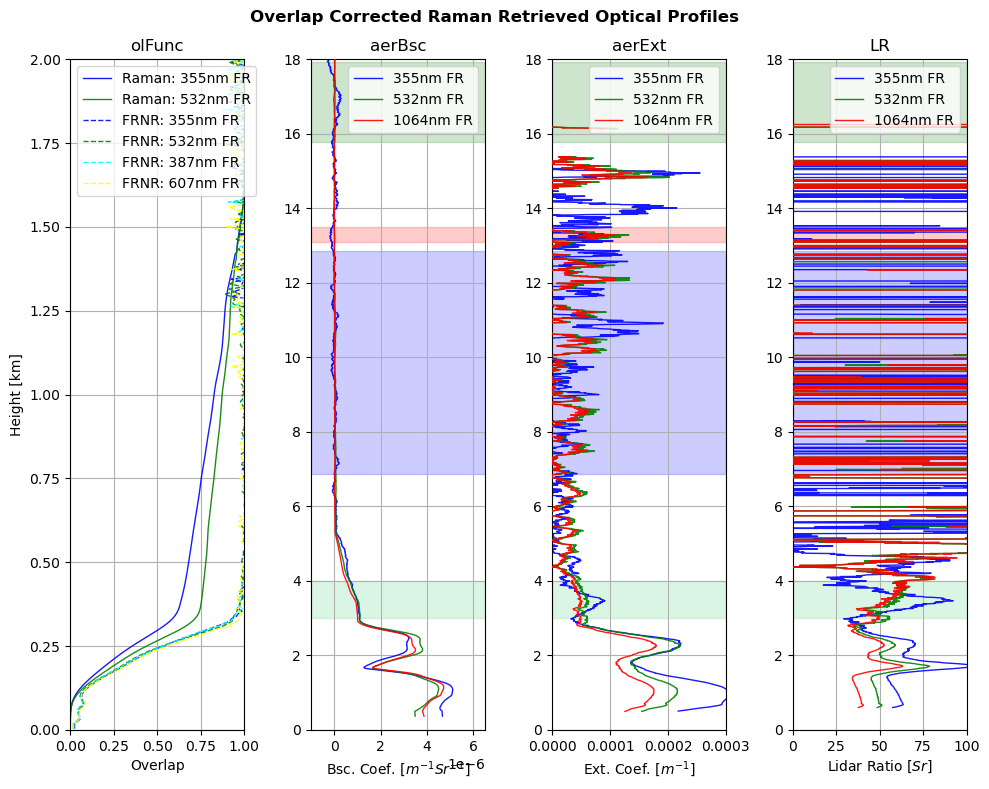

In [35]:
fig, ax = plt.subplots(1, 4, figsize=(10, 8))
## Overlap Function
ax[0].plot(data_cube.retrievals_profile['overlap']['raman'][grpIdx]['355_total_FR']['olFunc'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, linestyle='solid', label='Raman: 355nm FR')
ax[0].plot(data_cube.retrievals_profile['overlap']['raman'][grpIdx]['532_total_FR']['olFunc'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, linestyle='solid', label='Raman: 532nm FR')
ax[0].plot(data_cube.retrievals_profile['overlap']['frnr'][grpIdx]['355_total_FR']['olFunc'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, linestyle='dashed', label='FRNR: 355nm FR')
ax[0].plot(data_cube.retrievals_profile['overlap']['frnr'][grpIdx]['532_total_FR']['olFunc'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, linestyle='dashed', label='FRNR: 532nm FR')
ax[0].plot(data_cube.retrievals_profile['overlap']['frnr'][grpIdx]['387_total_FR']['olFunc'], data_cube.retrievals_highres['height']/1000, color='cyan', alpha=0.9, linewidth=1, linestyle='dashed', label='FRNR: 387nm FR')
ax[0].plot(data_cube.retrievals_profile['overlap']['frnr'][grpIdx]['607_total_FR']['olFunc'], data_cube.retrievals_highres['height']/1000, color='yellow', alpha=0.9, linewidth=1, linestyle='dashed', label='FRNR: 607nm FR')
ax[0].grid()
ax[0].set_ylim(0, 2)
ax[0].set_xlim(0, 1)
ax[0].legend(loc='upper left')
ax[0].set_ylabel('Height [km]')
ax[0].set_xlabel('Overlap')
ax[0].set_title('olFunc')

## Aerosol backscatter
ax[1].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['355_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR', zorder=2)
ax[1].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['532_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR', zorder=3)
ax[1].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['1064_total_FR']['aerBsc'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR', zorder=4)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_NR']['refHeight'])/1000,  color='lightblue', alpha=0.2)
ax[1].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_NR']['refHeight'])/1000,  color='lightgreen', alpha=0.2)
ax[1].grid()
ax[1].set_ylim(0, 18)
ax[1].set_xlim(-1e-6, 6.5e-6)
ax[1].legend(loc='upper right')
ax[1].set_xlabel('Bsc. Coef. $[m^{-1}Sr^{-1}]$')
ax[1].set_title('aerBsc')

## Aerosol Extinction
ax[2].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['355_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR', zorder=2)
ax[2].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['532_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR', zorder=3)
ax[2].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['1064_total_FR']['aerExt'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR', zorder=4)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_NR']['refHeight'])/1000,  color='lightblue', alpha=0.2)
ax[2].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_NR']['refHeight'])/1000,  color='lightgreen', alpha=0.2)
ax[2].grid()
ax[2].set_ylim(0, 18)
ax[2].set_xlim(-1e-6, 3e-4)
ax[2].legend(loc='upper right')
ax[2].set_xlabel('Ext. Coef. $[m^{-1}]$')
ax[2].set_title('aerExt')

## Lidar Ratio
ax[3].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['355_total_FR']['LR'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR', zorder=2)
ax[3].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['532_total_FR']['LR'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR', zorder=3)
ax[3].plot(data_cube.retrievals_profile['raman_OC'][grpIdx]['1064_total_FR']['LR'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR', zorder=4)
ax[3].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_FR']['refHeight'])/1000, color='blue', alpha=0.2)
ax[3].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_FR']['refHeight'])/1000, color='green', alpha=0.2)
ax[3].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['1064_total_FR']['refHeight'])/1000, color='red', alpha=0.2)
ax[3].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['355_total_NR']['refHeight'])/1000,  color='lightblue', alpha=0.2)
ax[3].axhspan(*np.array(data_cube.retrievals_profile['refH'][grpIdx]['532_total_NR']['refHeight'])/1000,  color='lightgreen', alpha=0.2)
ax[3].grid()
ax[3].set_ylim(0, 18)
ax[3].set_xlim(0, 100)
ax[3].legend(loc='upper right')
ax[3].set_xlabel('Lidar Ratio $[Sr]$')
ax[3].set_title('LR')
fig.suptitle("Overlap Corrected Raman Retrieved Optical Profiles", fontweight='bold')
fig.tight_layout()

## Depol and Ångström Profiles

Retrieval of Volume and Particle depolarization as well as Ångström 355/532 backscatter 532/1064 backscatter, adn 355/532 Extinction

In [36]:
## Volume and particle depolarization
data_cube.calcDepol()

2026-05-11 10:58:13,258 - INFO - voldepol at channel 532 cldFree 0 (np.int64(0), np.int64(114))
2026-05-11 10:58:13,261 - INFO - voldepol at channel 355 cldFree 0 (np.int64(0), np.int64(114))
2026-05-11 10:58:13,263 - INFO - voldepol at channel 1064 cldFree 0 (np.int64(0), np.int64(114))
2026-05-11 10:58:13,266 - INFO - voldepol at channel 532 cldFree 1 (np.int64(144), np.int64(245))
2026-05-11 10:58:13,269 - INFO - voldepol at channel 355 cldFree 1 (np.int64(144), np.int64(245))
2026-05-11 10:58:13,271 - INFO - voldepol at channel 1064 cldFree 1 (np.int64(144), np.int64(245))
2026-05-11 10:58:13,275 - INFO - pardepol at channel 532 cldFree 0 (np.int64(0), np.int64(114))
2026-05-11 10:58:13,277 - INFO - pardepol at channel 355 cldFree 0 (np.int64(0), np.int64(114))
2026-05-11 10:58:13,279 - INFO - pardepol at channel 1064 cldFree 0 (np.int64(0), np.int64(114))
2026-05-11 10:58:13,280 - INFO - pardepol at channel 532 cldFree 1 (np.int64(144), np.int64(245))
2026-05-11 10:58:13,281 - INF

klett
no_profiles  2
dict_keys(['532_total_FR', '355_total_FR', '1064_total_FR', '532_total_NR', '355_total_NR'])
532_total_FR 12.380587648929659
G [1.] [1.] H [-0.01477] [-0.9987] Eta 12.380587648929659 error [ 0.00027  0.02024 -0.00463] Window 25 
est. mdr 532_total_FR  0.006980075890695062 0.0004123753149513847
G [1.] [1.] H [-0.01477] [-0.9987] Eta 12.380587648929659 error [ 0.00027  0.02024 -0.00463] Window 1 
est. mdr 532_total_FR  -0.002564597803008701 0.000360376986442669  (smooth1)
dict_keys(['aerBsc', 'aerBscStd', 'aerBR', 'aerBRStd', 'aerExt', 'aerExtStd', 'retrieval', 'signal', 'refBeta', 'vdr', 'vdrStd', 'mdr', 'mdrStd'])
355_total_FR 47.742418057789656
G [1.] [1.] H [0.02041] [-0.998] Eta 47.742418057789656 error [ 0.00016  0.01567 -0.00958] Window 25 
est. mdr 355_total_FR  0.007487748125272333 0.0002782226384317622
G [1.] [1.] H [0.02041] [-0.998] Eta 47.742418057789656 error [ 0.00016  0.01567 -0.00958] Window 1 
est. mdr 355_total_FR  0.008694584490275539 0.0002999015

In [37]:
## Ångström ratios
data_cube.Angstroem()

klett
channels available 355_total_FR 532_total_FR Bsc
channels available 355_total_NR 532_total_NR Bsc
channels available 532_total_FR 1064_total_FR Bsc
channels available 355_total_FR 532_total_FR Ext
channels available 355_total_NR 532_total_NR Ext
channels available 355_total_FR 532_total_FR Bsc
channels available 355_total_NR 532_total_NR Bsc
channels available 532_total_FR 1064_total_FR Bsc
channels available 355_total_FR 532_total_FR Ext
channels available 355_total_NR 532_total_NR Ext
raman
channels available 355_total_FR 532_total_FR Bsc
channels available 355_total_NR 532_total_NR Bsc
channels available 532_total_FR 1064_total_FR Bsc
channels available 355_total_FR 532_total_FR Ext
channels available 355_total_NR 532_total_NR Ext
channels available 355_total_FR 532_total_FR Bsc
channels available 355_total_NR 532_total_NR Bsc
channels available 532_total_FR 1064_total_FR Bsc
channels available 355_total_FR 532_total_FR Ext
channels available 355_total_NR 532_total_NR Ext
klet

### Plot example: Depol and Ångström ratio profiles

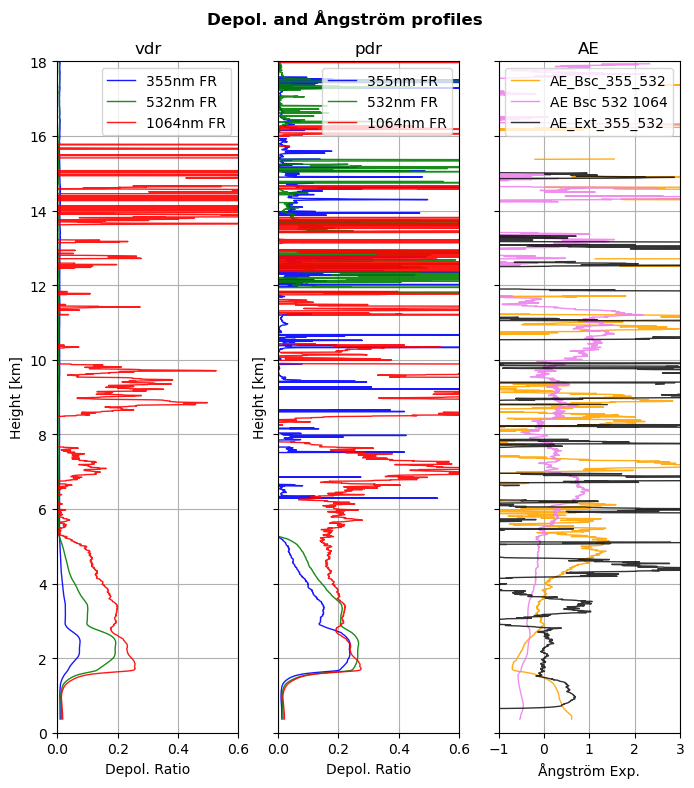

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(7, 8), sharey=True)
## Volume Depolarization Ratio
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['vdr'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR')
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_FR']['vdr'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR')
ax[0].plot(data_cube.retrievals_profile['raman'][grpIdx]['1064_total_FR']['vdr'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR')
ax[0].grid()
ax[0].set_ylim(0, 18)
ax[0].set_xlim(-1e-3, 6e-1)
ax[0].legend(loc='upper right')
ax[0].set_ylabel('Height [km]')
ax[0].set_xlabel('Depol. Ratio')
ax[0].set_title('vdr')

## Particle Depolarization Ratio
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['pdr'], data_cube.retrievals_highres['height']/1000, color='blue', alpha=0.9, linewidth=1, label='355nm FR')
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_FR']['pdr'], data_cube.retrievals_highres['height']/1000, color='green', alpha=0.9, linewidth=1, label='532nm FR')
ax[1].plot(data_cube.retrievals_profile['raman'][grpIdx]['1064_total_FR']['pdr'], data_cube.retrievals_highres['height']/1000, color='red', alpha=0.9, linewidth=1, label='1064nm FR')
ax[1].grid()
ax[1].set_ylim(0, 18)
ax[1].set_xlim(-1e-3, 6e-1)
ax[1].legend(loc='upper right')
ax[1].set_ylabel('Height [km]')
ax[1].set_xlabel('Depol. Ratio')
ax[1].set_title('pdr')

## Ångström ratios at cloud free period 0
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['AE_Bsc_355_532'], data_cube.retrievals_highres['height']/1000, color='orange', alpha=0.9, linewidth=1, label='AE_Bsc_355_532')
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['532_total_FR']['AE_Bsc_532_1064'], data_cube.retrievals_highres['height']/1000, color='violet', alpha=0.9, linewidth=1, label='AE Bsc 532 1064')
ax[2].plot(data_cube.retrievals_profile['raman'][grpIdx]['355_total_FR']['AE_Ext_355_532'], data_cube.retrievals_highres['height']/1000, color='black', alpha=0.8, linewidth=1, label='AE_Ext_355_532')
ax[2].grid()
ax[2].set_ylim(0, 18)
ax[2].set_xlim(-1, 3)
ax[2].legend(loc='upper right')
ax[2].set_xlabel('Ångström Exp.')
ax[2].set_title('AE')
fig.suptitle("Depol. and Ångström profiles", fontweight='bold')
fig.tight_layout()


## Lidar Calibration

- Lidar calibration constants (LC) are retieved for each channel at each cloud free period for both Klett and Raman retieved profiles
- All retrieved LCs are stored in the database
- If no LCs can be retrieved for a given channel, the LCs in the time range [24h before the measurment, 24h after the measurement] for the given channel included in the database will be used
- The optimal LC, ie. the one with the lowest standard deviation per channel is used for the processing.
- The following priority order is used when choosing the optimal LC
    1. Raman retrieved LC from data
    2. Klett retrieved LC from data
    3. Raman retrieved LC from database
    4. Klett retrieved LC from database

In [39]:
## Lidar calcibration for both Klett and Raman retrival
data_cube.LidarCalibration(db_path=DATABASE_PATH)

2026-05-11 10:58:13,865 - INFO - LC retrieval: klett method
2026-05-11 10:58:13,873 - INFO - Using Retrieved Exticntion
2026-05-11 10:58:13,929 - INFO - cldFreGrp 0, Channel 532 total FR, LC_stable 110519246161610.45, LCStd 0.0022345184524830176
2026-05-11 10:58:13,936 - INFO - Using Retrieved Exticntion
2026-05-11 10:58:13,994 - INFO - cldFreGrp 0, Channel 355 total FR, LC_stable 25673613689464.64, LCStd 0.001697933679133036
2026-05-11 10:58:14,001 - INFO - Using Retrieved Exticntion
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\misc\helper.py:907: RuntimeWarning: Mean of empty slice
  thisMean = np.nanmean(window)
2026-05-11 10:58:14,084 - INFO - cldFreGrp 0, Channel 1064 total FR, LC_stable 70707728983268.77, LCStd 0.0030263297684652185
2026-05-11 10:58:14,093 - INFO - Using Retrieved Exticntion
2026-05-11 10:58:14,195 - INFO - cldFreGrp 0, Channel 532 total NR, LC_stable 7339709186305.094, LCStd 0.0014185825176983608
2026-05-11 10:58:14,201 - INFO - Using Retrieved Exticntion

In [40]:
## Display Lidar calibration constants per channel
data_cube.LCused

{'1064_total_FR': np.float64(51000118564518.48),
 '355_total_FR': np.float64(16667136285998.08),
 '355_total_NR': np.float64(2698389817432.6167),
 '532_total_FR': np.float64(113827580950926.9),
 '532_total_NR': np.float64(8686033355261.775),
 '387_total_FR': np.float64(48944093882776.27),
 '387_total_NR': np.float64(4007540841170.811),
 '607_total_FR': np.float64(290981081297381.9),
 '607_total_NR': np.float64(13499399145944.1)}

In [41]:
## Store calibration constants in database
data_cube.write_2_sql_db(db_path=str(DATABASE_PATH), parameter='LC', method='raman')
data_cube.write_2_sql_db(db_path=str(DATABASE_PATH), parameter='LC', method='klett')
data_cube.write_2_sql_db(db_path=str(DATABASE_PATH), parameter='DC')

2026-05-11 10:58:15,719 - INFO - writing to sqlite-db: PicassoPyDatabase.db
2026-05-11 10:58:15,720 - INFO - writing LC to table: lidar_calibration_constant
2026-05-11 10:58:15,729 - INFO - 18 rows inserted into 'lidar_calibration_constant'.
2026-05-11 10:58:15,730 - INFO - writing to sqlite-db: PicassoPyDatabase.db
2026-05-11 10:58:15,731 - INFO - writing LC to table: lidar_calibration_constant
2026-05-11 10:58:15,738 - INFO - 10 rows inserted into 'lidar_calibration_constant'.
2026-05-11 10:58:15,741 - INFO - writing to sqlite-db: PicassoPyDatabase.db
2026-05-11 10:58:15,742 - INFO - writing DC to table: depol_calibration_constant
2026-05-11 10:58:15,750 - INFO - 3 rows inserted into 'depol_calibration_constant'.


dict_keys(['klett', 'raman', 'klett_db', 'raman_db'])
dict_keys(['klett', 'raman', 'klett_db', 'raman_db'])
dict_keys(['klett', 'raman', 'klett_db', 'raman_db'])


In [42]:
## Save retrived optical profiles
write_profile2nc_file(data_cube=data_cube, prod_ls=["profiles", "NR_profiles", "OC_profiles"], collect_debug=True)

2026-05-11 10:58:15,763 - INFO - saving product: profiles
2026-05-11 10:58:15,877 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_0000_0056_profiles.nc
2026-05-11 10:58:16,294 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_0112_0202_profiles.nc
2026-05-11 10:58:16,622 - INFO - saving product: NR_profiles
2026-05-11 10:58:16,732 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_0000_0056_NR_profiles.nc
2026-05-11 10:58:16,980 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_0112_0202_NR_profiles.nc
2026-05-11 10:58:17,132 - INFO - saving product: OC_profiles
2026-05-11 10:58:17,245 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_0000_0056_OC_profiles.nc
2026-05-11 10:58:17,648 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_0112_0202_OC_profiles.nc


## High Resoulution Retrievals

The following high resolution (30s) time-height data are retrieved: 

- Attenuated backscatter
- Volume depolarization
- Molecular backscatter and extinction
- Quality mask
- QuasiV1 and QuasiV2 retrievals
- Target categorization V1 and V2

In [43]:
## Highres attenuated backscatter and volume depolarization
data_cube.attBsc_volDepol()

## Highres molecular signal
data_cube.molecularHighres()

2026-05-11 10:58:17,931 - INFO - attBsc 2d retrieval
2026-05-11 10:58:18,335 - INFO - and even a 355 channel


Exprimental, attenuated backscatter solution for 387_total_NR
G [1.] [1.]
H [0.02041] [-0.998]
polCaliEta 47.742418057789656
G [1.] [1.] H [0.02041] [-0.998] Eta 47.742418057789656 error [ 0.00016  0.01567 -0.00958] Window 1 


2026-05-11 10:58:18,525 - INFO - and even a 532 channel


calculated R_t [0.95999647]
G [1.] [1.]
H [-0.01477] [-0.9987]
polCaliEta 12.380587648929659
G [1.] [1.] H [-0.01477] [-0.9987] Eta 12.380587648929659 error [ 0.00027  0.02024 -0.00463] Window 1 
calculated R_t [1.02998285]


2026-05-11 10:58:18,720 - INFO - and even a 1064 channel


G [1.] [1.]
H [-0.02439] [-0.996]
polCaliEta 0.14153155793311498
G [1.] [1.] H [-0.02439] [-0.996] Eta 0.14153155793311498 error [ 0.00133  0.02379 -0.01205] Window 1 
calculated R_t [1.04999949]


2026-05-11 10:58:19,037 - INFO - voldepol 2d retrieval


G [1.] [1.] H [-0.01477] [-0.9987] Eta 12.380587648929659 error [ 0.00027  0.02024 -0.00463] Window 1 
G [1.] [1.] H [0.02041] [-0.998] Eta 47.742418057789656 error [ 0.00016  0.01567 -0.00958] Window 1 
G [1.] [1.] H [-0.02439] [-0.996] Eta 0.14153155793311498 error [ 0.00133  0.02379 -0.01205] Window 1 


### Plot Example: Highres Attenuated Backscatterm & Volume Depolarization

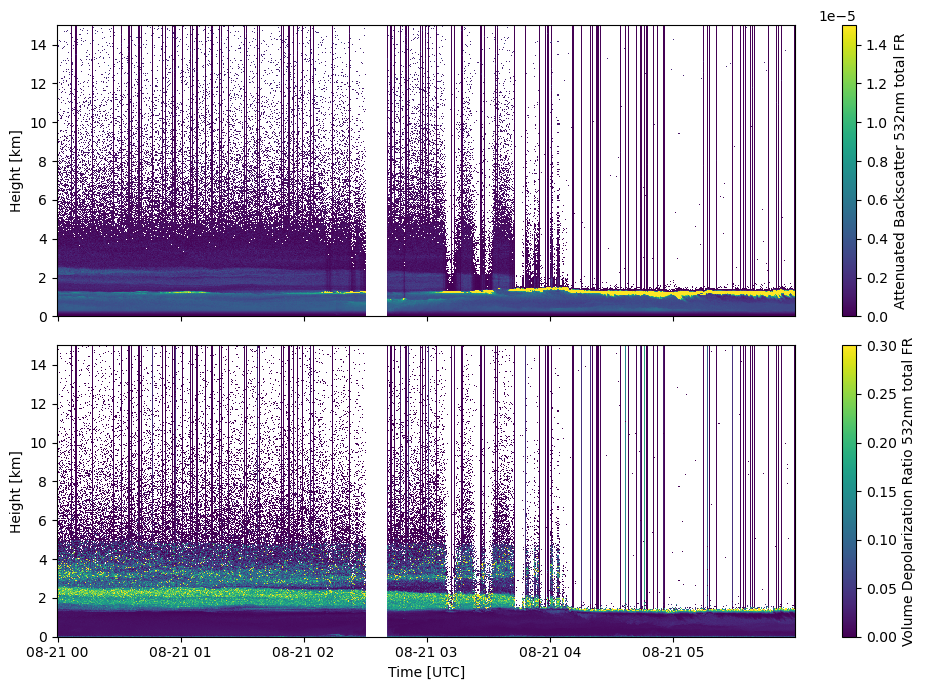

In [44]:
wv, t, tel = 532, 'total', 'FR'

fig, ax = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
pcmeshATB = ax[0].pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    data_cube.retrievals_highres[f'attBsc_{wv}_{t}_{tel}'].T,
    shading='nearest',
    vmin=0, vmax=1.5e-5
)
cbar = fig.colorbar(pcmeshATB)
cbar.set_label(f'Attenuated Backscatter {wv}nm {t} {tel}')
ax[0].set_ylabel('Height [km]')
ax[0].set_ylim(0, 15)

pcmeshVD = ax[1].pcolormesh(
    data_cube.retrievals_highres['time64'],
    data_cube.retrievals_highres['height']/1000,
    data_cube.retrievals_highres[f'voldepol_{wv}_{t}_{tel}'].T,
    shading='nearest',
    vmin=0, vmax=0.3
)
cbar = fig.colorbar(pcmeshVD)
cbar.set_label(f'Volume Depolarization Ratio {wv}nm {t} {tel}')
ax[1].set_xlabel('Time [UTC]')
ax[1].set_ylabel('Height [km]')
ax[1].set_ylim(0, 15)
fig.tight_layout()

In [45]:
## Quality mask of signal
data_cube.estQualityMask()

['FR-total-355 nm', 'FR-cross-355 nm', 'FR-387 nm', 'FR-407 nm', 'FR-total-532 nm', 'FR-cross-532 nm', 'FR-607 nm', 'FR-total-1064 nm', 'NR-total-532 nm', 'NR-607 nm', 'NR-total-355 nm', 'NR-387 nm', 'DFOV', '1058', '1064s']
shape of quality mask (720, 4000, 15)
0 FR-total-355 nm
1 FR-cross-355 nm
2 FR-387 nm
3 FR-407 nm
4 FR-total-532 nm
5 FR-cross-532 nm
6 FR-607 nm
7 FR-total-1064 nm
8 NR-total-532 nm
9 NR-607 nm
10 NR-total-355 nm
11 NR-387 nm
12 DFOV
13 1058
14 1064s


### Plot example: Quality Mask

C:\Users\buholdt\AppData\Local\Temp\ipykernel_13624\4235260950.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Set3', 6),


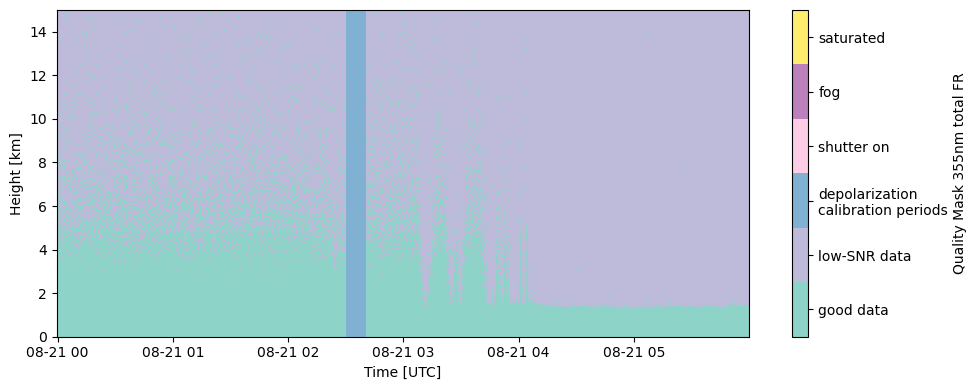

In [46]:
fig, ax = plt.subplots(figsize=(10, 4))
pcmesh = ax.pcolormesh(
    data_cube.retrievals_highres['time64'], 
    np.array(data_cube.retrievals_highres['height'])/1000, 
    np.squeeze(data_cube.retrievals_highres['quality_mask'][:, :, data_cube.gf(355, 'total', 'FR')]).T, 
    shading='nearest',
    cmap=plt.cm.get_cmap('Set3', 6),
    vmin=-0.5, vmax=5.5
)

cats = {
    0: "good data",
    1: "low-SNR data",
    2: "depolarization\ncalibration periods",
    3: "shutter on",
    4: "fog",
    5: "saturated"
}
formatter = plt.FuncFormatter(lambda val, loc:cats[val])
cbar = fig.colorbar(pcmesh, ticks=np.arange(0, 6), format=formatter)
cbar.set_label('Quality Mask 355nm total FR')
ax.set_ylim(0, 15)
ax.set_ylabel('Height [km]')
ax.set_xlabel("Time [UTC]")
fig.tight_layout()

In [47]:
## QuasiV1 retrievals and Target categorization
data_cube.quasiV1()

(720, 4000) 1 5
(720, 4000) (720, 4000)
hFullOverlap 900 120


c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV1.py:112: RuntimeWarning: divide by zero encountered in divide
  quasi_par_bsc = att_beta / (mol_att * quasi_par_att) ** 2 - molBsc
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV1.py:112: RuntimeWarning: overflow encountered in divide
  quasi_par_bsc = att_beta / (mol_att * quasi_par_att) ** 2 - molBsc
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV1.py:114: RuntimeWarning: overflow encountered in multiply
  quasi_par_ext = quasi_par_bsc * LRaer
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV1.py:111: RuntimeWarning: overflow encountered in multiply
  quasi_par_att = np.exp(-np.nancumsum(quasi_par_ext * diff_height, axis=1))


(720, 4000) 1 5
(720, 4000) (720, 4000)
hFullOverlap 800 107


c:\Users\buholdt\AppData\Local\miniconda3\envs\PicassoPy\Lib\site-packages\numpy\_core\fromnumeric.py:57: RuntimeWarning: overflow encountered in accumulate
  return bound(*args, **kwds)


(720, 4000) 1 5
(720, 4000) (720, 4000)
hFullOverlap 800 107
G [1.] [1.] H [-0.01477] [-0.9987] Eta 12.380587648929659 error [ 0.00027  0.02024 -0.00463] Window 1 


c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasi.py:58: RuntimeWarning: divide by zero encountered in divide
  quasi_pdr = (vdr + 1) / (mBsc * (molDepol - vdr) / quasi_bsc / (1 + molDepol) + 1) - 1
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasi.py:73: RuntimeWarning: divide by zero encountered in divide
  ratio_par_bsc = data_cube.retrievals_highres[f'quasiBsc{version}_532_{t}_{tel}'] / \
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasi.py:73: RuntimeWarning: invalid value encountered in divide
  ratio_par_bsc = data_cube.retrievals_highres[f'quasiBsc{version}_532_{t}_{tel}'] / \
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasi.py:320: RuntimeWarning: overflow encountered in divide
  if np.min(bsc1064[hIndLargeBsc:(hIndLargeBsc + jump_hBins), iTime] / bsc1064[hIndLargeBsc, iTime]) < (1 / minAttnRatioBsc1064):


### Plot example: Target Categorization Version 1

C:\Users\buholdt\AppData\Local\Temp\ipykernel_13624\316367719.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Set3', 12),


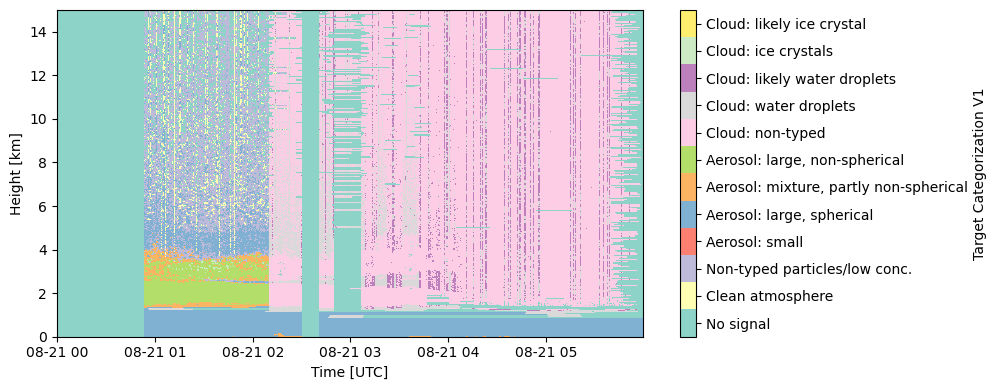

In [48]:
fig, ax = plt.subplots(figsize=(10, 4))
pcmesh = ax.pcolormesh(
    data_cube.retrievals_highres['time64'],
    np.array(data_cube.retrievals_highres['height'])/1000, 
    data_cube.retrievals_highres['tcMaskV1'].T,
    shading='nearest',
    cmap=plt.cm.get_cmap('Set3', 12),
    vmin=-0.5, vmax=11.5
)

cats = {
    0: 'No signal',
    1: 'Clean atmosphere',
    2: 'Non-typed particles/low conc.',
    3: 'Aerosol: small',
    4: 'Aerosol: large, spherical',
    5: 'Aerosol: mixture, partly non-spherical',
    6: 'Aerosol: large, non-spherical',
    7: 'Cloud: non-typed',
    8: 'Cloud: water droplets',
    9: 'Cloud: likely water droplets',
    10: 'Cloud: ice crystals',
    11: 'Cloud: likely ice crystal',
}
formatter = plt.FuncFormatter(lambda val, loc:cats[val])
cbar = fig.colorbar(pcmesh, ticks=np.arange(0, 12), format=formatter)
cbar.set_label('Target Categorization V1')
ax.set_ylim(0, 15)
ax.set_ylabel('Height [km]')
ax.set_xlabel('Time [UTC]')
fig.tight_layout()

In [49]:
## QuasiV2 retrievals and Target categorization
data_cube.quasiV2()

c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV2.py:115: RuntimeWarning: divide by zero encountered in divide
  quasi_par_bsc = (att_beta_el / att_beta_ra) * quasi_par_att - molBscEl
c:\Users\buholdt\AppData\Local\miniconda3\envs\PicassoPy\Lib\site-packages\numpy\_core\fromnumeric.py:57: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV2.py:114: RuntimeWarning: overflow encountered in exp
  quasi_par_att = np.exp((1 - (wv / wv_r) ** AE) * OD_par + (OD_mol - OD_mol_r)) * molBscEl
c:\Users\buholdt\Documents\PicassoPy\tests\..\ppcpy\retrievals\quasiV2.py:112: RuntimeWarning: overflow encountered in exp
  quasi_par_att = np.exp((2 - (1064 / 607) ** AE - (1064 / 532) ** AE) * OD_par + (2 * OD_mol - OD_mol_532 - OD_mol)) * molBsc532


G [1.] [1.] H [-0.01477] [-0.9987] Eta 12.380587648929659 error [ 0.00027  0.02024 -0.00463] Window 1 


### Plot example: Target Categorization Version 2

C:\Users\buholdt\AppData\Local\Temp\ipykernel_13624\906464641.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap('Set3', 12),


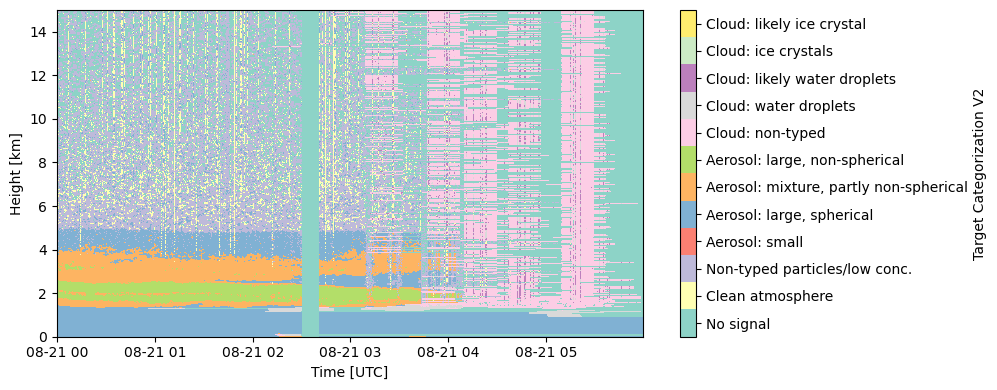

In [53]:
fig, ax = plt.subplots(figsize=(10, 4))
pcmesh = ax.pcolormesh(
    data_cube.retrievals_highres['time64'],
    np.array(data_cube.retrievals_highres['height'])/1000, 
    data_cube.retrievals_highres['tcMaskV2'].T,
    shading='nearest',
    cmap=plt.cm.get_cmap('Set3', 12),
    vmin=-0.5, vmax=11.5
)

cats = {
    0: 'No signal',
    1: 'Clean atmosphere',
    2: 'Non-typed particles/low conc.',
    3: 'Aerosol: small',
    4: 'Aerosol: large, spherical',
    5: 'Aerosol: mixture, partly non-spherical',
    6: 'Aerosol: large, non-spherical',
    7: 'Cloud: non-typed',
    8: 'Cloud: water droplets',
    9: 'Cloud: likely water droplets',
    10: 'Cloud: ice crystals',
    11: 'Cloud: likely ice crystal',
}
formatter = plt.FuncFormatter(lambda val, loc:cats[val])
cbar = fig.colorbar(pcmesh, ticks=np.arange(0, 12), format=formatter)
cbar.set_label('Target Categorization V2')
ax.set_ylim(0, 15)
ax.set_ylabel('Height [km]')
ax.set_xlabel('Time [UTC]')
fig.tight_layout()

In [51]:
## Save highres retrivals
write2nc_file(data_cube=data_cube, prod_ls=["att_bsc", "NR_att_bsc", "OC_att_bsc", "vol_depol", "quasi_results", "quasi_results_V2", "target_classification", "target_classification_V2"])

2026-05-11 10:58:46,435 - INFO - saving product: att_bsc
2026-05-11 10:58:46,584 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_att_bsc.nc
2026-05-11 10:58:48,256 - INFO - saving product: NR_att_bsc
2026-05-11 10:58:48,411 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_NR_att_bsc.nc
2026-05-11 10:58:49,147 - INFO - saving product: OC_att_bsc
2026-05-11 10:58:49,242 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_OC_att_bsc.nc
2026-05-11 10:58:50,066 - INFO - saving product: vol_depol
2026-05-11 10:58:50,163 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_vol_depol.nc


removing variable: volume_depolarization_ratio_532nm_DFOV


2026-05-11 10:58:50,621 - INFO - saving product: quasi_results
2026-05-11 10:58:50,709 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_quasi_results.nc


removing variable: quality_mask_355nm
removing variable: quality_mask_532nm
removing variable: quality_mask_1064nm
removing variable: quality_mask_voldepol_532


2026-05-11 10:58:52,647 - INFO - saving product: quasi_results_V2
2026-05-11 10:58:52,782 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_quasi_results_V2.nc


removing variable: quality_mask_355nm
removing variable: quality_mask_532nm
removing variable: quality_mask_1064nm
removing variable: quality_mask_voldepol_532


2026-05-11 10:58:56,683 - INFO - saving product: target_classification
2026-05-11 10:58:56,819 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_target_classification.nc
2026-05-11 10:58:56,962 - INFO - saving product: target_classification_V2
2026-05-11 10:58:57,080 - INFO - writing to file: pollyxt_cpv\2024\08\21\20240821_pollyxt_cpv_target_classification_V2.nc
